# genulens CLI examples

This notebook is a lightweight public guide to the historical `genulens` command-line interface. The v2 Python API is the recommended interface for new workflows, but the CLI remains available and useful for reproducing legacy commands.

The executed cells below are intentionally small. Long analysis-scale commands are listed at the end as references and are not executed by default.


In [1]:
from pathlib import Path
import os
import re
import shlex
import subprocess
from subprocess import PIPE

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Allow this notebook to be launched either from the repository root or examples/.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "examples" else cwd
output_dir = cwd

GENULENS_EXE = repo_root / "build" / "genulens"
if not GENULENS_EXE.exists():
    GENULENS_EXE = repo_root / "genulens"
if not GENULENS_EXE.exists():
    raise FileNotFoundError(
        "Could not find genulens executable. Build the project first, e.g. `cmake --build build`."
    )

GENULENS_CMD = "./build/genulens" if (repo_root / "build" / "genulens").exists() else "./genulens"

# Keep public notebook execution quick. Set True to reproduce the long-running examples.
RUN_LONG_CLI_EXAMPLES = False


In [2]:
# To run genulens through Python.

def get_header(argv):
    VERBOSITY, BINARY = 0, 0
    args = shlex.split(argv)
    for i, arg in enumerate(args):
        if arg == "VERBOSITY":
            VERBOSITY = int(args[i + 1])
        if arg == "BINARY":
            BINARY = int(args[i + 1])

    if VERBOSITY == 3:
        header = "wtj M_L D_L D_S t_E theta_E pi_E pi_EN pi_EE mu_rel mu_Sl mu_Sb I_L K_L iS iL fREM".split()
    elif VERBOSITY == 2:
        header = "wtj t_E theta_E pi_EN pi_EE D_S mu_Sl mu_Sb iS iL fREM".split()
    else:
        header = None
    if BINARY == 1 and VERBOSITY > 1:
        header += "q21 M2 aL aLpmin u0 BL".split()
    return header


def run_genulens(file, argv, ranseed=False, grep=False):
    args = shlex.split(argv)
    if ranseed:
        args += ["seed", str(np.random.randint(1, 10**10))]

    output_path = output_dir / file
    printable = " ".join([shlex.quote(GENULENS_CMD), *map(shlex.quote, args)])
    if grep:
        printable += f" | grep {grep}"
    display_output = output_path.name if output_path.parent == output_dir else str(output_path)
    printable += f" > {shlex.quote(display_output)}"
    print("# Conducted command (you can do this directly in your command line too):")
    print("\n", printable, "\n")

    proc = subprocess.run(
        [str(GENULENS_EXE), *args],
        cwd=repo_root,
        stdout=PIPE,
        stderr=PIPE,
        text=True,
        check=True,
    )
    stdout = proc.stdout
    if grep:
        pattern = re.compile(grep)
        stdout = "\n".join(line for line in stdout.splitlines() if pattern.search(line))
        if stdout:
            stdout += "\n"
    output_path.write_text(stdout)
    if proc.stderr:
        print(proc.stderr)
    return get_header(argv)


def show_header(file, line1=30, line2=43):
    output_path = output_dir / file
    lines = output_path.read_text().splitlines()
    selected = "\n".join(lines[line1 - 1:line2])
    display_path = output_path.name if output_path.parent == output_dir else str(output_path)
    print(f"\nshowing {display_path}, lines {line1}-{line2}\n")
    print(selected)


In [3]:
# To print the output 

def weighted_percentile(values, percentiles, weights=None, sw_sort=True, C= 0.5):                                                  
    """                                                                                                                            
    Get percentiles of unequal array
    Reference: 
    https://stackoverflow.com/questions/21844024/weighted-percentile-using-numpy
    See                                                                                                                            
    https://en.wikipedia.org/wiki/Percentile#The_weighted_percentile_method                                                        
    about the constant C that takes 0, 0.5 or 1                                                                                    
    """                                                                                                                            
    values = np.array(values)                                                                                                      
    percentiles = np.array(percentiles)                                                                                            
    if weights is None:                                                                                                            
        weights = np.ones(len(values))                                                                                             
    weights = np.array(weights)                                                                                                    
    assert np.all(percentiles >= 0) and np.all(percentiles <= 1), \
            'percentiles should be in [0, 1]'                                                                                      
    assert C==0 or C==0.5 or C==1, \
            'C should be 0, 0.5 or 1'                                                                                              
                                                                                                                                   
    if sw_sort:                                                                                                                    
        sorter = np.argsort(values)                                                                                                
        values = values[sorter]                                                                                                    
        weights = weights[sorter]                                                                                                  
                                                                                                                                   
    cumu_wts = np.cumsum(weights)                                                                                                  
    weighted_percentiles = (cumu_wts - C * weights) / (cumu_wts[-1] + (1-2*C)*weights)                                             
    return np.interp(percentiles, weighted_percentiles, values)                                                                    


def plot_hist_wt (axis, data, col = 'C1', log = 0, label = None, wt = None, NXBIN = 50) :
    xmin, xmax = weighted_percentile(data, [0.001, 0.999], weights=wt)
    if(log == 1) :
        xbins = np.logspace(np.log10(xmin), np.log10(xmax), num=NXBIN+1)
    else :
        xbins = np.linspace(xmin, xmax, num=NXBIN+1)
    y, x, pol = axis.hist(data, bins = xbins, histtype = 'step', linewidth = 2, color = col, label = label, weights = wt)
    xpers  = weighted_percentile(data, [0.1587, 0.50, 0.8413], weights=wt)
    # print (xpers)
    # xpers = np.percentile(data, q=100*np.array([0.1587, 0.50, 0.8413]))
    if log == 1 :
        xmids = 0.5 * (np.log10(xbins)[1:] + np.log10(xbins)[0:-1])
        dxpers = np.array([np.abs(xmids - np.log10(xper)) for xper in xpers])
        axis.set_xscale("log")
    else :
        xmids = 0.5 * (xbins[1:] + xbins[0:-1])
        dxpers = np.array([np.abs(xmids - xper) for xper in xpers])
    ix_pers = dxpers.argmin(1) 
    lss = ['--', '-', '--']
    for i, xeach in enumerate(xpers) :
        yeach = y[ix_pers[i]]
        axis.vlines(xeach, 0, yeach, ls = lss[i], color = col)
    return xpers
        
        
def print_data (file, header, DISP = True, usecols = None) :
    # Read the list
    data = np.loadtxt(file, usecols = usecols)
    if (DISP) :
        dataset = pd.DataFrame(data, columns=header)
        display(dataset)
        print("Unweighted statistics (just for reference) : ")
        display(dataset.describe())
    return data

def hist_wt (data, header, logparams = [], wtcol = None, PLOT = True, NXBIN = 50) :
    nparam = data.shape[1]
    dataT = data.T
    # Set wt array
    if wtcol is None :
        wt = np.ones(data.shape[0])
        wtcol = nparam + 1 # set non-exist column 
    else :
        wt =  dataT[wtcol]

    if PLOT:  # plot histogram
        if wtcol < nparam :
            print("Histogram weighted by ", header[wtcol], " : ")
        plt.rcParams["font.size"] = 13
        
        # Determine number of panels
        Nx = int(np.sqrt(nparam))
        if(Nx != np.sqrt(nparam)) : Nx += 1
        Ny = int(nparam / Nx)
        if(Nx * Ny < nparam) : Ny += 1

        fig, ax = plt.subplots(Ny, Nx, figsize=(14, 14*Ny/Nx))
        plt.subplots_adjust(wspace=0.4, hspace=0.4)


        for i in range(Ny*Nx) :
            # Skip wtcol param
            if i == wtcol : 
                continue

            # Get (ix, iy)
            if i < wtcol :
                ix = int(i/Nx)
                iy = i % Nx
            else :
                ix = int((i-1)/Nx)
                iy = (i-1) % Nx
                if i == Ny*Nx - 1 :
                    ax[int(i/Nx), i % Nx].axis('off') # deactivate the panel unused due to wtcol

            if i >= nparam :
                ax[ix,iy].axis('off')
                continue

            if (header[i] in logparams) :
                LOG = 1
            else :
                LOG = 0

            # print(header[i])
            plot_hist_wt(ax[ix, iy], dataT[i], col = 'C0', log = LOG, wt = wt, NXBIN = NXBIN)
            if iy == 0 : 
                ax[ix,iy].set_ylabel(r'Number', fontsize = 16)
            ax[ix,iy].set_xlabel('{}'.format(header[i]), fontsize = 16)
            # ax[ix,iy].legend(fontsize = 18, loc='upper left')


    # percentiles = np.array([weighted_percentile(dataT[i], [0.0228, 0.1587, 0.50, 0.8413, 0.9772], weights=wt) for i in range(nparam)])
    percentiles = np.zeros([nparam, 5])
    for i in range(nparam) :
        if i == wtcol : continue
        percentiles[i] = weighted_percentile(dataT[i], [0.0228, 0.1587, 0.50, 0.8413, 0.9772], weights=wt)
    
    return percentiles


## Example 1: a small constrained event sample

This example applies simple `tE`, `thetaE`, lens-flux, and extinction constraints. It uses a small `NlikeMIN` so the notebook remains quick to execute.


In [4]:
arg_basic = ''
arg_basic += ' l -0.08 b -3.45'
arg_basic += ' tE 34.0 2.2'
arg_basic += ' thetaE 0.28 0.03'
arg_basic += ' IL 20.67 0.47 ILdet 2'
arg_basic += ' AIrc 1.63'
arg_basic += ' VERBOSITY 3'

file_basic = 'cli_sample_basic.dat'
header_basic = run_genulens(file_basic, arg_basic + ' NlikeMIN 200')


# Conducted command (you can do this directly in your command line too):

 ./build/genulens l -0.08 b -3.45 tE 34.0 2.2 thetaE 0.28 0.03 IL 20.67 0.47 ILdet 2 AIrc 1.63 VERBOSITY 3 NlikeMIN 200 > cli_sample_basic.dat 



In [5]:
show_header(file_basic, 30, 46)



showing cli_sample_basic.dat, lines 30-46

#   rho5: rho0b=  4.12, (x0,y0,z0,Rc)= ( 931, 371,240,2632), (C1,C2,C3)= (1.2,4.1,1.0)
#     X5: rho0X=  5.93, (x0,y0,z0,Rc)= ( 278, 176,287,1302)
#   (Omega_p, vx_str)= (47.4 km/s/kpc,  43[1-e^{-(|yb|/ 407)^2}] km/s)
#   ND= 0  SH= 1
#---------- Input parameters ----------
#    CenSgrA= 1
#    UNIFORM= 0
#    REMNANT= 0     BINARY= 0
#   (Nsimu, NlikeMIN)= (100000, 200)
#          (l, b, PA)= ( -0.08,  -3.45, 60.28) deg.
#     tE = 34.000 +- 2.200 det= 0
# thetaE = 0.280 +- 0.030 det= 0
#  Consider 14.00 < Is < 21.00, (hdust,Dmean,AIrc,AI0)=(164,8194,1.63,1.71)
#     tErange     : 25.2000 - 42.8000
#     thetaErange : 0.1600 - 0.4000
#----- Mass density along (l,b)= (-0.080,-3.450) --------
#     0  8160    32  0: 1.1e-02 ( 0.00e+00 ) 1: 1.5e-02 ( 0.00e+00 ) 2: 1.3e-02 ( 0.00e+00 ) 3: 1.2e-02 ( 0.00e+00 ) 4: 2.3e-02 ( 0.00e+00 ) 5: 2.6e-02 ( 0.00e+00 ) 6: 5.5e-02 ( 0.00e+00 ) 7: 9.1e-03 ( 0.00e+00 ) 8: 4.9e-33 ( 0.00e+00 ) 9: 0.0e+00 ( 0.00e

In [6]:
df_basic = pd.DataFrame(np.loadtxt(file_basic), columns=header_basic)
df_basic[['wtj', 'M_L', 'D_L', 'D_S', 't_E', 'theta_E', 'pi_E']].head()


,wtj,M_L,D_L,D_S,t_E,theta_E,pi_E
0,0.029849,0.857063,6444.0,7007.0,31.36112,0.294974,0.042261
1,0.089503,1.012533,7505.0,8397.0,33.41072,0.341611,0.041428
2,0.054532,1.147133,7273.0,7974.0,33.25401,0.335859,0.035951
3,0.046496,0.938063,6942.0,7450.0,34.85505,0.274039,0.035871
4,0.038424,0.923125,7207.0,7754.0,30.22848,0.271390,0.036100


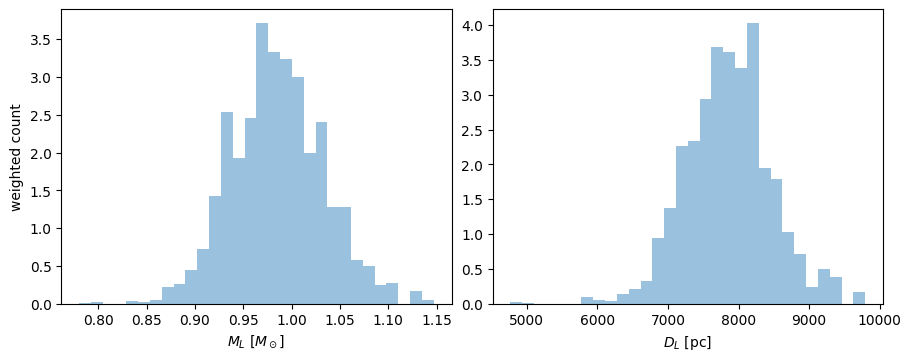

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].hist(df_basic['M_L'], bins=30, weights=df_basic['wtj'], histtype='stepfilled', alpha=0.45)
axes[0].set_xlabel(r'$M_L$ [$M_\odot$]')
axes[0].set_ylabel('weighted count')
axes[1].hist(df_basic['D_L'], bins=30, weights=df_basic['wtj'], histtype='stepfilled', alpha=0.45)
axes[1].set_xlabel(r'$D_L$ [pc]')
plt.show()


## Example 2: source-distance and parallax-oriented CLI options

`Isrange`, `VIsrange`, `AIrc`, `EVIrc`, and `DMrc` modify the source-distance distribution. When `AIrc` is supplied, the legacy CLI also activates a default lens-flux constraint unless `IL` is specified. This example sets `IL 99 0` to disable that implicit lens-flux constraint because the purpose here is to demonstrate source selection and parallax-related output.


In [8]:
arg_parallax = ''
arg_parallax += ' l 2.47 b -2.00'
arg_parallax += ' vEarthlb -24.3835 13.0860'
arg_parallax += ' tE 16.00 0.50 thetaE 0.207 0.050 UNIFORM 1'
arg_parallax += ' Isrange 19.8 20.4 AIrc 1.96'
arg_parallax += ' VIsrange 2.24 2.44 EVIrc 1.66 DMrc 14.47'
arg_parallax += ' IL 99 0'
arg_parallax += ' SMALLGAMMA 1 VERBOSITY 3'

file_parallax = 'cli_sample_parallax.dat'
header_parallax = run_genulens(file_parallax, arg_parallax + ' NlikeMIN 200')


# Conducted command (you can do this directly in your command line too):

 ./build/genulens l 2.47 b -2.00 vEarthlb -24.3835 13.0860 tE 16.00 0.50 thetaE 0.207 0.050 UNIFORM 1 Isrange 19.8 20.4 AIrc 1.96 VIsrange 2.24 2.44 EVIrc 1.66 DMrc 14.47 IL 99 0 SMALLGAMMA 1 VERBOSITY 3 NlikeMIN 200 > cli_sample_parallax.dat 



In [9]:
df_parallax = pd.DataFrame(np.loadtxt(file_parallax), columns=header_parallax)
df_parallax[['wtj', 'pi_EN', 'pi_EE', 'D_S', 'mu_rel', 'iS', 'iL']].head()


,wtj,pi_EN,pi_EE,D_S,mu_rel,iS,iL
0,0.003512,0.430197,-0.214779,8094.0,3.838753,8.0,5.0
1,0.014190,-0.080944,-0.026617,8199.0,4.138441,8.0,8.0
2,0.000917,-0.048297,0.680255,7079.0,4.995623,6.0,6.0
3,0.001670,0.126772,-0.021470,6249.0,4.228103,4.0,5.0
4,0.007423,0.020742,-0.026616,7396.0,5.685340,8.0,8.0


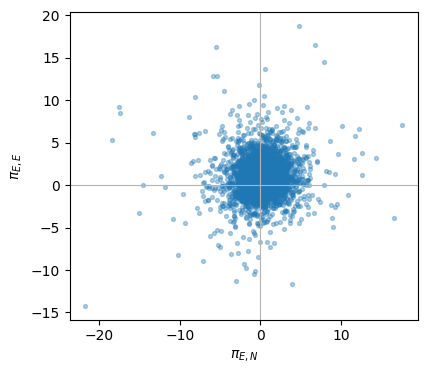

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(df_parallax['pi_EN'], df_parallax['pi_EE'], s=8, alpha=0.35)
ax.set_xlabel(r'$\pi_{E,N}$')
ax.set_ylabel(r'$\pi_{E,E}$')
ax.axhline(0, color='0.7', lw=0.8)
ax.axvline(0, color='0.7', lw=0.8)
plt.show()


## Example 3: remnant option smoke run

This is a small smoke run showing the `REMNANT` option. Analysis-scale remnant or black-hole population studies usually require much larger `Nsimu` values and are therefore not executed in this public notebook.


In [11]:
arg_remnant = ''
arg_remnant += ' l 1.45 b -2.13'
arg_remnant += ' vEarthlb -13.24 19.67'
arg_remnant += ' Isrange 15.30 15.60 AIrc 1.42'
arg_remnant += ' VIsrange 1.89 2.54 EVIrc 1.14 DMrc 14.494'
arg_remnant += ' IL 17.7 0.01 ILdet 2'
arg_remnant += ' SMALLGAMMA 1 REMNANT 1 VERBOSITY 3'

file_remnant = 'cli_sample_remnant.dat'
header_remnant = run_genulens(file_remnant, arg_remnant + ' Nsimu 20000')


# Conducted command (you can do this directly in your command line too):

 ./build/genulens l 1.45 b -2.13 vEarthlb -13.24 19.67 Isrange 15.30 15.60 AIrc 1.42 VIsrange 1.89 2.54 EVIrc 1.14 DMrc 14.494 IL 17.7 0.01 ILdet 2 SMALLGAMMA 1 REMNANT 1 VERBOSITY 3 Nsimu 20000 > cli_sample_remnant.dat 



In [12]:
df_remnant = pd.DataFrame(np.loadtxt(file_remnant), columns=header_remnant)
summary = df_remnant.groupby('fREM').agg(count=('wtj', 'size'), weight=('wtj', 'sum'))
summary


,count,weight
fREM,,
0.0,4,0.555352
1.0,1918,705.647044
2.0,106,114.509871
3.0,44,63.398931


## Long legacy commands, not executed

The historical example notebook included several analysis-scale runs, such as high-resolution parallax-vector studies and black-hole kick-velocity reproductions. They are useful references, but they are intentionally not executed here.

Use these only when you really want the full legacy calculation and have checked the expected runtime.


In [13]:
long_commands = [
    arg_parallax + ' NlikeMIN 1e+6 seed 1',
    arg_remnant + ' tE 288.8 8.0 piEN -0.033 0.001 piEE -0.073 0.004 NlikeMIN 500',
    'l -0.14 b -1.62 REMNANT 1 VERBOSITY 3 vkickBH 400 MXDkick 1 BHhd 1 UseSigBH 1 Nsimu 3e+7',
]
for command in long_commands:
    print(GENULENS_CMD, command)


./build/genulens  l 2.47 b -2.00 vEarthlb -24.3835 13.0860 tE 16.00 0.50 thetaE 0.207 0.050 UNIFORM 1 Isrange 19.8 20.4 AIrc 1.96 VIsrange 2.24 2.44 EVIrc 1.66 DMrc 14.47 IL 99 0 SMALLGAMMA 1 VERBOSITY 3 NlikeMIN 1e+6 seed 1
./build/genulens  l 1.45 b -2.13 vEarthlb -13.24 19.67 Isrange 15.30 15.60 AIrc 1.42 VIsrange 1.89 2.54 EVIrc 1.14 DMrc 14.494 IL 17.7 0.01 ILdet 2 SMALLGAMMA 1 REMNANT 1 VERBOSITY 3 tE 288.8 8.0 piEN -0.033 0.001 piEE -0.073 0.004 NlikeMIN 500
./build/genulens l -0.14 b -1.62 REMNANT 1 VERBOSITY 3 vkickBH 400 MXDkick 1 BHhd 1 UseSigBH 1 Nsimu 3e+7


## Cleanup


In [14]:
for file in [file_basic, file_parallax, file_remnant]:
    try:
        os.remove(file)
    except FileNotFoundError:
        pass
